# 01. 전력망을 계산 문제로 바꾸기

전력망은 처음에는 bus와 branch가 연결된 graph처럼 보인다. 전력조류 계산은 그 graph를 바로 푸는 것이 아니라, sparse matrix와 복소 전압 방정식으로 바꿔 푼다.

- 물리 객체: bus, branch, generator, load
- 계산 객체: `Ybus`, `Sbus`, `V`
- 풀 방정식: `S_calc(V) - S_spec = 0`

$$
S_{calc}(V) = V \odot \overline{Y_{bus}V}
$$

`case9`는 성능 측정용이 아니라 변환 과정을 눈으로 확인하기 위한 작은 예제다. 큰 계통에서도 같은 변환이 일어나고, sparse Jacobian과 sparse linear solve 병목은 여기서 시작된다.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False
pd.set_option('display.max_colwidth', 120)


In [2]:
case = tu.load_case('case9')
print(f"case={case.case_name}, buses={case.ybus.shape[0]}, branches={case.branch.shape[0]}, ybus_nnz={case.ybus.nnz}")
display(pd.DataFrame([
    {'object': 'bus', 'in calculation': 'one row/column of Ybus and one voltage V_i'},
    {'object': 'branch / transformer', 'in calculation': 'off-diagonal admittance and diagonal self admittance'},
    {'object': 'generator', 'in calculation': 'positive P/Q contribution to S_spec'},
    {'object': 'load', 'in calculation': 'negative P/Q contribution to S_spec'},
]))


case=case9, buses=9, branches=9, ybus_nnz=27


,object,in calculation
0,bus,one row/column of Ybus and one voltage V_i
1,branch / transformer,off-diagonal admittance and diagonal self admittance
2,generator,positive P/Q contribution to S_spec
3,load,negative P/Q contribution to S_spec


**Graph가 Newton 문제로 바뀌는 세 단계**

- 왼쪽: bus type과 branch 연결을 본다.
- 가운데: topology가 `Ybus` sparse pattern으로 바뀐다.
- 오른쪽: Slack/PV/PQ 규칙에 따라 Newton이 푸는 전압 state가 정해진다.

Slack bus는 기준 각도와 전압 크기가 주어지고, PV bus는 전압 크기가 주어진다. 그래서 Newton state는 `Va(PV,PQ)`와 `Vm(PQ)`만 포함한다.

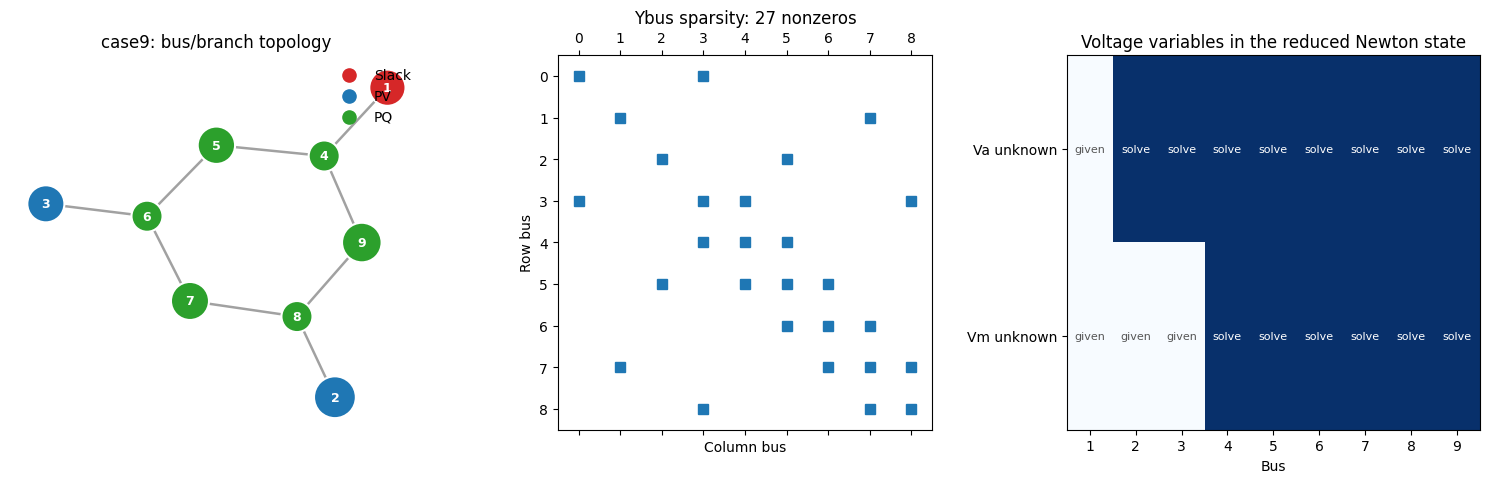

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
tu.plot_network_to_ybus_story(case, axes)
plt.tight_layout()

**초기 전압에서 mismatch 확인**
- `V0`는 아직 정답이 아니다.
- 그래서 `S_calc(V0)`와 `S_spec`이 다르다.
- 이 차이가 다음 노트북에서 Newton-Raphson이 줄일 대상이다.


In [4]:
snap = tu.power_flow_snapshot(case, case.v0)
print(f"reduced mismatch length={snap.mismatch_reduced.size}, inf_norm={np.linalg.norm(snap.mismatch_reduced, np.inf):.3e}")
display(tu.power_flow_bus_table(snap, limit=9).round(6))


reduced mismatch length=14, inf_norm=1.630e+00


,bus,|V|,Va_deg,P_spec,Q_spec,P_calc,Q_calc,P_mis,Q_mis
0,1,1.040,0.0,0.723,0.2703,0.0,0.722222,-0.723,0.451922
1,2,1.025,0.0,1.630,0.0654,0.0,0.410000,-1.630,0.344600
2,3,1.025,0.0,0.850,-0.1095,0.0,0.437287,-0.850,0.546787
3,4,1.000,0.0,0.000,0.0000,-0.0,-0.861444,-0.000,-0.861444
4,5,1.000,0.0,-0.900,-0.3000,0.0,-0.258000,0.900,0.042000
5,6,1.000,0.0,0.000,0.0000,0.0,-0.710121,0.000,-0.710121
6,7,1.000,0.0,-1.000,-0.3500,0.0,-0.179000,1.000,0.171000
7,8,1.000,0.0,0.000,0.0000,-0.0,-0.627500,-0.000,-0.627500
8,9,1.000,0.0,-1.250,-0.5000,0.0,-0.241000,1.250,0.259000


**다음 단계로 넘어가기 전 정리**
- `V`가 바뀌면 `S_calc(V)`도 비선형으로 바뀐다.
- 한 번의 선형 solve로 끝나지 않는다.
- Newton-Raphson은 현재 `V` 주변에서 선형화하고, mismatch가 작아질 때까지 반복한다.
